In [19]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

############
# parameters
############

N_arr = np.arange(2, 10, 2)
nmax  = 20
ω = ω0 = g = 1.0


#############################
# Tavis–Cummings Hamiltonian
#############################

def tavis_cummings(N, nmax, ω, ω0, g):

    a  = qt.destroy(nmax)
    Ic = qt.qeye(nmax)

    sp, sm, sz = qt.sigmap(), qt.sigmam(), qt.sigmaz()

    def embed(op, i):
        ops = [qt.qeye(2)]*N
        ops[i] = op
        return qt.tensor(ops)

    Sp = sum(embed(sp, i) for i in range(N))
    Sm = Sp.dag()
    Sz = 0.5 * sum(embed(sz, i) for i in range(N))

    IB = qt.tensor([qt.qeye(2)]*N)
    HB = Sz + 0.5 * N * IB

    
    H = (ω * qt.tensor(a.dag()*a, IB) + ω0 * qt.tensor(Ic, HB) + g * (qt.tensor(a, Sp) + qt.tensor(a.dag(), Sm)))

    return H, HB

##################
# Initial state
################## 
    
def initial_state(N, nmax, state):

    if state == "coherent":
        psiA = qt.coherent(nmax, np.sqrt(N))
    elif state == "fock":
        psiA = qt.basis(nmax, N)
    psiB = qt.tensor([qt.basis(2, 1) for _ in range(N)])
    
    return qt.tensor(psiA, psiB)

##############
# Pnm matrix
##############

def pnm_matrix(rho, H):

    r_val, r_vec = rho.eigenstates()
    idx = np.argsort(r_val)[::-1]
    r_val = r_val[idx]
    r_vec = [r_vec[i] for i in idx]

    e_val, e_vec = H.eigenstates()

    pnm = np.zeros((len(e_val), len(e_val)))
    for n in range(len(e_val)):
        for m in range(len(e_val)):
            pnm[n, m] = r_val[m]*abs(e_vec[n].overlap(r_vec[m]))**2

    return pnm, r_val, e_val
    

############################
# ergotropy using pnm matrix
############################

def ergotropy_pnm(pnm, r_val, e_val):
    deltaE = e_val[:,None] - e_val[None,:]
    return np.sum(pnm * deltaE)


############################
# variance using pnm matrix
############################

def variance_pnm(pnm, r_val, e_val):
    deltaE2 = (e_val[:,None] - e_val[None,:])**2
    mean2 = np.sum(pnm * deltaE2)
    mean = ergotropy_pnm(pnm, r_val, e_val)
    return mean2 - mean**2


/var/folders/__/qnt7415x1x54dvh7_jpmptp40000gp/T/ipykernel_50438/2574795428.py:85: RuntimeWarning: invalid value encountered in divide
  ratio = np.divide(Erg, EB)


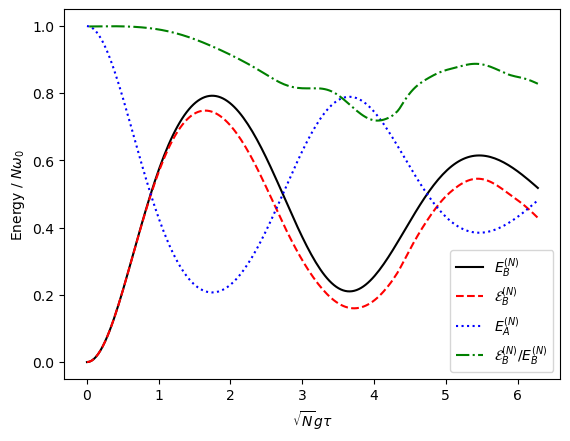

In [20]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

###############
# Parameters
###############

N = 8
g = 1.0
ω0 = 1.0
ω = 1.0
nmax = 20
times = np.linspace(0, 2*np.pi/np.sqrt(N), 200)
x = np.sqrt(N) * g * times

############################
# Tavis–Cummings Hamiltonian
############################

def tavis_cummings(N, nmax, ω, ω0, g):

    a  = qt.destroy(nmax)
    Ic = qt.qeye(nmax)

    sp, sm, sz = qt.sigmap(), qt.sigmam(), qt.sigmaz()

    def embed(op, i):
        ops = [qt.qeye(2)]*N
        ops[i] = op
        return qt.tensor(ops)

    Sp = sum(embed(sp, i) for i in range(N))
    Sm = Sp.dag()
    Sz = 0.5 * sum(embed(sz, i) for i in range(N))

    IB = qt.tensor([qt.qeye(2)]*N)

    # Atomic Hamiltonian 
    HB_atoms = ω0 * (Sz + 0.5 * N * IB)

    # Full Hamiltonian
    HA = ω * qt.tensor(a.dag()*a, IB)
    HB_full = qt.tensor(Ic, HB_atoms)
    H = HA + HB_full + g * (qt.tensor(a, Sp) + qt.tensor(a.dag(), Sm))

    return H, HA, HB_atoms

###################
# Initial state
###################

ψ0 = initial_state(N, nmax, "coherent")

H, HA, HB = tavis_cummings(N, nmax, ω, ω0, g)

######################
# Time evolution
######################

result = qt.sesolve(H, ψ0, times)

###############
# Observables
###############

EB, EA, Erg, Var = [], [], [], []

for s in result.states:
    rhoB = s.ptrace(list(range(1,N+1)))     # atoms
    rhoA = s.ptrace(0)                     # cavity

    pnm, r_val, e_val = pnm_matrix(rhoB, HB)

    erg = ergotropy_pnm(pnm, r_val, e_val)

    EB.append(qt.expect(HB, rhoB))
    EA.append(qt.expect(HA, s))   
    Erg.append(erg)

EB  = np.array(EB)  / (N*ω0)
EA  = np.array(EA)  / (N*ω0)
Erg = np.array(Erg) / (N*ω0)

ratio = np.divide(Erg, EB)

###########
# Plot
###########

plt.plot(x, EB,  'k-',  label=r'$E_B^{(N)}$')
plt.plot(x, Erg, 'r--', label=r'$\mathcal{E}_B^{(N)}$')
plt.plot(x, EA,  'b:',  label=r'$E_A^{(N)}$')
plt.plot(x, ratio, 'g-.', label=r'$\mathcal{E}_B^{(N)}/E_B^{(N)}$')


plt.xlabel(r'$\sqrt{N} g \tau$')
plt.ylabel(r'Energy / $N\omega_0$')
plt.legend()
plt.show()

/var/folders/__/qnt7415x1x54dvh7_jpmptp40000gp/T/ipykernel_50438/1628430616.py:122: RuntimeWarning: invalid value encountered in divide
  ratio = np.divide(Erg, EB)


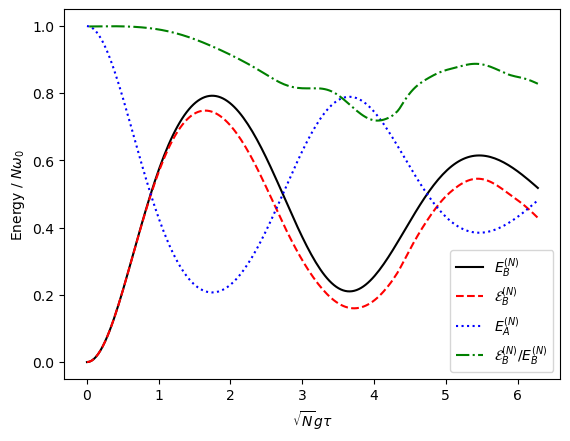

In [21]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

###############
# Parameters
###############

N = 8
g = 1.0
ω0 = 1.0
ω = 1.0
nmax = 20
times = np.linspace(0, 2*np.pi/np.sqrt(N), 200)
x = np.sqrt(N) * g * times

############################
# Tavis–Cummings Hamiltonian
############################

def tavis_cummings(N, nmax, ω, ω0, g):

    a  = qt.destroy(nmax)
    Ic = qt.qeye(nmax)

    sp, sm, sz = qt.sigmap(), qt.sigmam(), qt.sigmaz()

    def embed(op, i):
        ops = [qt.qeye(2)]*N
        ops[i] = op
        return qt.tensor(ops)

    Sp = sum(embed(sp, i) for i in range(N))
    Sm = Sp.dag()
    Sz = 0.5 * sum(embed(sz, i) for i in range(N))

    IB = qt.tensor([qt.qeye(2)]*N)

    # Atomic Hamiltonian 
    HB_atoms = ω0 * (Sz + 0.5 * N * IB)

    # Full Hamiltonian
    HA = ω * qt.tensor(a.dag()*a, IB)
    HB_full = qt.tensor(Ic, HB_atoms)
    H = HA + HB_full + g * (qt.tensor(a, Sp) + qt.tensor(a.dag(), Sm))

    return H, HA, HB_atoms
    
##################
# Initial state
##################

def initial_state(N, nmax, state):

    if state == "coherent":
        psiA = qt.coherent(nmax, np.sqrt(N))
    elif state == "fock":
        psiA = qt.basis(nmax, N)

    psiB = qt.tensor([qt.basis(2, 1) for _ in range(N)])
    return qt.tensor(psiA, psiB)

###################
# Initial state
###################

ψ0 = initial_state(N, nmax, "coherent")

H, HA, HB = tavis_cummings(N, nmax, ω, ω0, g)

######################
# Time evolution
######################

result = qt.sesolve(H, ψ0, times)


###############
# Observables
###############

E_B, E_A, Erg = [], [], []

for s in result.states:
    rhoB = s.ptrace(list(range(1,N+1)))     # atoms
    rhoA = s.ptrace(0)                     # cavity
    
    EB = qt.expect(HB, rhoB)

    EA = qt.expect(HA, s)
    
    r_vals, r_vecs = rhoB.eigenstates()
    
    idx = np.argsort(r_vals)[::-1]
    r_vals = r_vals[idx]
    r_vecs = [r_vecs[i] for i in idx]
   
    # Passive Hamiltonian constructed in the passive state's eigenbasis
    
    e_vals, e_vecs = HB.eigenstates()
    
    H_passive = sum(e_vals[i] * r_vecs[i] * r_vecs[i].dag() for i in range(len(e_vals)))

    # Ergotropy operator defined w.r.t. passive Hamiltonian
    
    E_op = HB - H_passive
    
    E_erg = qt.expect(E_op, rhoB)

    E_B.append(EB)
    E_A.append(EA)
    Erg.append(E_erg)

EB  = np.array(E_B)  / (N*ω0)
EA  = np.array(E_A)  / (N*ω0)
Erg = np.array(Erg) / (N*ω0)

ratio = np.divide(Erg, EB)

###########
# Plot
###########

plt.plot(x, EB,  'k-',  label=r'$E_B^{(N)}$')
plt.plot(x, Erg, 'r--', label=r'$\mathcal{E}_B^{(N)}$')
plt.plot(x, EA,  'b:',  label=r'$E_A^{(N)}$')
plt.plot(x, ratio, 'g-.', label=r'$\mathcal{E}_B^{(N)}/E_B^{(N)}$')

plt.xlabel(r'$\sqrt{N} g \tau$')
plt.ylabel(r'Energy / $N\omega_0$')
plt.legend()
plt.show()